# Support visualisation

## Configuration du notebook

In [1]:
import numpy as np
import scipy as sp
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from IPython.display import display, clear_output
import ipywidgets as widgets

## Entropie

In [2]:
def entropy(p):
    eps = np.finfo(float).eps
    p = np.clip(p, eps, 1.0 - eps)
    return -p * np.log(p) - (1 - p) * np.log(1 - p)

In [3]:
def crossed_entropy(p, q):
    eps = np.finfo(float).eps
    p = np.clip(p, eps, 1.0 - eps)
    q = np.clip(q, eps, 1.0 - eps)
    return -p * np.log(q) - (1 - p) * np.log(1 - q)

In [4]:
def relative_entropy(p, q):
    return crossed_entropy(p, q) - entropy(p)

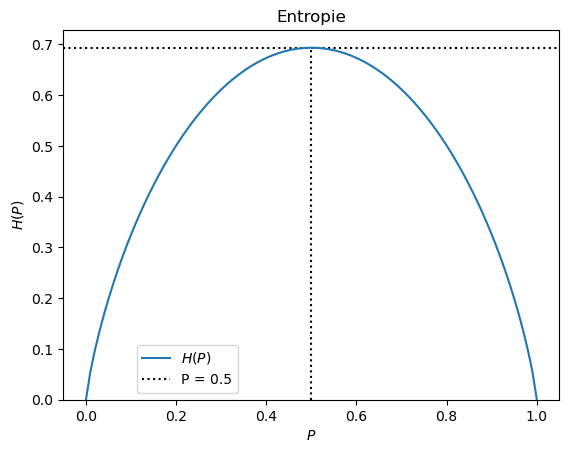

In [5]:
p = np.linspace(0., 1., 100)
plt.plot(p, entropy(p), label=r"$H(P)$", zorder=10)
plt.vlines(0.5, 0., entropy(0.5), color="k", ls=":", label=r"P = 0.5")
plt.axhline(entropy(0.5), color="k", ls=":")
plt.xlabel(r"$P$")
plt.ylabel(r"$H(P)$")
plt.ylim(0., None)
# plt.xlim(0., 1.)
plt.legend(loc="lower center", bbox_to_anchor=(0.25, 0.));
plt.title("Entropie");

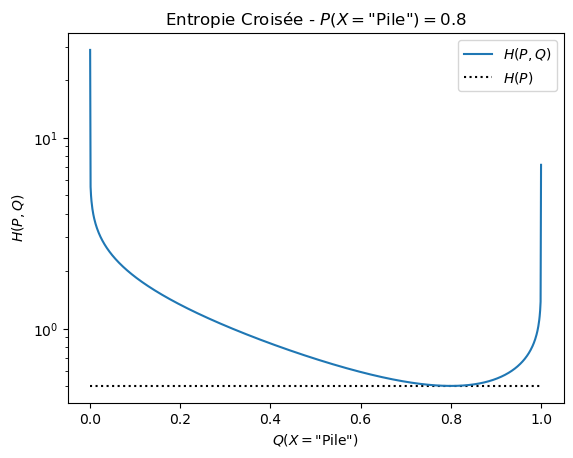

In [6]:
p = np.full(1000, 0.8)
q = np.linspace(0., 1., 1000)
plt.plot(q, crossed_entropy(p, q), label=r"$H(P,Q)$", zorder=10)
plt.plot(q, entropy(p), color="k", ls=":", label=r"$H(P)$")
plt.yscale("log")
plt.xlabel(r"$Q(X = \text{\"Pile\"})$")
plt.ylabel(r"$H(P,Q)$")
# plt.xlim(0., 1.)
plt.legend()
plt.title(r"Entropie Croisée - $P(X = \text{\"Pile\"}) = 0.8$");

In [7]:
entropy(0.8), crossed_entropy(0.8, 0.7)

(np.float64(0.5004024235381879), np.float64(0.5261345160161731))

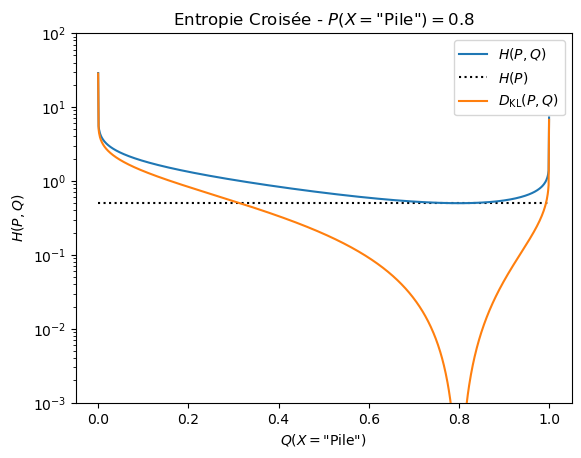

In [8]:
p = np.full(1000, 0.8)
q = np.linspace(0., 1., 1000)
plt.plot(q, crossed_entropy(p, q), label=r"$H(P,Q)$", zorder=10)
plt.plot(q, entropy(p), color="k", ls=":", label=r"$H(P)$")
plt.plot(q, relative_entropy(p, q), label=r"$D_{\text{KL}}(P,Q)$", zorder=10)
plt.yscale("log")
plt.xlabel(r"$Q(X = \text{\"Pile\"})$")
plt.ylabel(r"$H(P,Q)$")
#plt.xlim(0., 1.)
plt.ylim(0.001, 100)
plt.legend()
plt.title(r"Entropie Croisée - $P(X = \text{\"Pile\"}) = 0.8$");

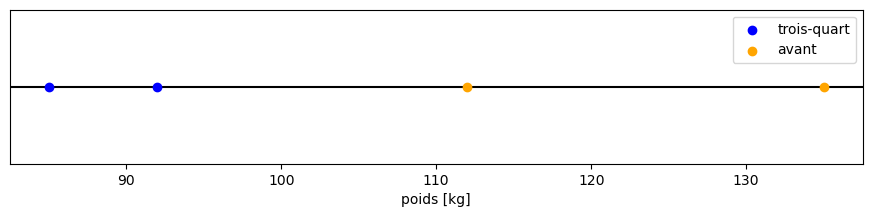

In [9]:
poste = np.array([1, 0, 1, 0])  # 0 pour trois-quart et 1 pour avant
poids = np.array([112., 85., 135., 92.])  # en kilogrammes
fig = plt.figure(figsize=(11, 2))
ax = fig.add_subplot(111)
ax.scatter(poids[poste==0], np.zeros(2), c="blue", label="trois-quart")
ax.scatter(poids[poste==1], np.zeros(2), c="orange", label="avant")
ax.axhline(0., c="k", zorder=0)
ax.set_xlabel("poids [kg]")
ax.legend();
ax.get_yaxis().set_visible(False);

In [10]:
def rugby():
    # Données des joueurs de rugby
    X1 = np.array([175., 180., 193., 185., 186., 185., 177., 182., 181., 184., 184., 203., 200., 205., 197., 203., 203., 195., 199., 
                   190., 191., 194., 190., 192., 174., 169., 182., 177., 175., 184., 186., 185., 190., 190., 184., 194., 192., 188., 
                   183., 188., 184., 185., 182., 178.]).reshape(-1, 1)  # taille 
    X2 = np.array([115., 119., 142., 112., 133., 124., 125., 107., 110., 109., 112., 142., 105., 133., 122., 138., 116., 108., 114., 
                   111., 114., 108., 90., 107., 86., 82., 83., 83., 75., 86., 94., 89., 98., 100., 97., 94., 108., 102., 95., 97., 
                   84., 84., 84., 87.]).reshape(-1, 1)  # poids
    Y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
                  0, 0, 0, 0, 0, 0]).reshape(-1, 1)  # 1 avant, 0 trois-quart
    return X1, X2, np.hstack((X1, X2)), Y

In [11]:
def lineaire(n=100, sigma=1):
    X1 = np.random.uniform(-4, 4, n).reshape(-1, 1)
    X2 = np.random.uniform(-4, 4, n).reshape(-1, 1)
    Y = np.zeros(n).reshape(-1, 1)
    mask = X1 + X2 + 1 >= 0
    Y[mask] = 1
    X1 += np.random.normal(0., sigma, n).reshape(-1, 1)
    X2 += np.random.normal(0., sigma, n).reshape(-1, 1)
    return X1, X2, np.hstack((X1, X2)), Y

In [12]:
def lunes(n=100, noise=0.15):
    X_data, Y_data = make_moons(n_samples=n, noise=noise)
    X_data *= 4
    return X_data[:, [0]], X_data[:, [1]], X_data, Y_data.reshape(-1, 1)

In [13]:
class Node:
    def __init__(self, x, y, depth=0, min_entropy=0., min_size=1, max_depth=1):
        self.__x = x
        self.__y = y
        self.__children = []
        self.__depth = depth
        self.__processed = False
        self.__min_entropy = min_entropy
        self.__min_size = min_size
        self.__max_depth = max_depth
        self.__feature = None
        self.__xs = None
        self.__prediction = None
    
    def stop_criterion(self):
        # check wether or not the node shall be split
        criterion = False
        if self.get_depth() >= self.__max_depth:
            criterion = True
        if self.get_size() <= self.__min_size:
            criterion = True
        if self.entropy(self.__y)[0] <= self.__min_entropy:
            criterion = True
        return criterion
    
    def search(self):
        n = self.__x.shape[0]
        d = self.__x.shape[1]
        # Overall best candidate
        optimal_feature = None
        optimal_x = None
        optimal_entropy = np.inf
        # Loop on features
        for j in range(d):
            # Initialisation of best candidate
            local_optimal_x = None
            local_optimal_entropy = np.inf
            # Sort feature in increasing order
            sort = np.argsort(self.__x[:, j])
            _x = self.__x[sort, j]
            _y = self.__y[sort]
            # Loop on mid-points:
            _xu = np.unique(_x)
            for i in range(_xu.shape[0] - 1):
                xs = (_xu[i + 1] + _xu[i]) / 2.0
                left = _y[_x <= xs]
                right = _y[_x > xs]
                entropy = self.weighted_entropy(left, right)
                # print("Feature: ", j, "entropy: ", entropy, "x*: ", xs)
                if entropy <= local_optimal_entropy:
                    local_optimal_entropy = entropy
                    local_optimal_x = xs
                    # print("BEST ==> Feature: ", j, "entropy: ", local_optimal_entropy, "x*: ", local_optimal_x)
            # Overall best candidate
            if local_optimal_entropy < optimal_entropy:
                optimal_feature = j
                optimal_x = local_optimal_x
                optimal_entropy = local_optimal_entropy
                # print("ABSOLUTE BEST ==> Feature: ", optimal_feature, "entropy: ", optimal_entropy, "x*: ", optimal_x)
        return (optimal_feature, optimal_x, optimal_entropy)

    def check(self, feature, x):
        mask = self.__x[:, feature] < x
        print("Left:")
        print(self.__x[mask])
        print(self.__y[mask])
        h1, w1 = self.group_entropy(self.__y[mask])
        print("Entropy:", h1)
        print("Size:", w1)
        print("Right:")
        print(self.__x[~mask])
        print(self.__y[~mask])
        h2, w2 = self.group_entropy(self.__y[~mask])
        print("Entropy:", h2)
        print("Size:", w2)
        print("Weighted entropy: ", (w1 * h1 + w2 * h2) / (w1 + w2))

    def split(self, feature, x):
        mask = self.__x[:, feature] < x
        self.__children.append(Node(self.__x[mask], self.__y[mask], self.__depth + 1, self.__min_entropy, self.__min_size, self.__max_depth))
        self.__children.append(Node(self.__x[~mask], self.__y[~mask], self.__depth + 1, self.__min_entropy, self.__min_size, self.__max_depth))

    def process(self):
        # check stop criterion
        if self.stop_criterion():
            self.__prediction = self.__y.sum() / self.__y.shape[0]
            self.__processed = True
            return
        # otherwise split
        optimal_feature, optimal_x, optimal_entropy = self.search()
        self.split(optimal_feature, optimal_x)
        self.__processed = True
        self.__feature = optimal_feature
        self.__xs = optimal_x
        return optimal_feature, optimal_x
        
    def entropy(self, y=None):
        if y is None:
            y = self.get_y()
        w = y.shape[0]
        if w == 0:
            return 0., 0
        p = y.sum() / w
        return entropy(p), w

    def weighted_entropy(self, left, right):
        h1, w1 = self.entropy(left)
        h2, w2 = self.entropy(right)
        return (w1 * h1 + w2 * h2) / (w1 + w2)

    def nodes_to_process(self):
        # Collect all nodes to be processed
        candidates = []
        # If current node is not processed, add it and return
        if not self.__processed:
            candidates.append(self)
            return candidates
        # Otherwise look within children:
        for child in self.__children:
            candidates.extend(child.nodes_to_process())
        return candidates

    def _predict(self, x):
        # If this node is a leave we return the prediction
        if len(self.__children) == 0:
            return self.__prediction
    
        # Else we ask to children
        if x[self.__feature] < self.__xs:
            return self.__children[0]._predict(x)
        else:
            return self.__children[1]._predict(x)

    def get_depth(self):
        return self.__depth

    def get_size(self):
        return self.__x.shape[0]

    def get_feature(self):
        return self.__feature

    def get_xs(self):
        return self.__xs

    def get_children(self):
        return self.__children
        
    def get_x(self):
        return self.__x

    def get_y(self):
        return self.__y

    def get_prediction(self):
        return self.__prediction

    def __str__(self):
        return (f"Node(size={self.get_size()}, depth={self.get_depth()}, min_entropy={self.__min_entropy}, " 
                f"min_size={self.__min_size}, max_depth={self.__max_depth})")


class Tree(Node):
    def __init__(self, x, y, min_entropy=0., min_size=1, max_depth=1):
        super().__init__(x, y, depth=0, min_entropy=min_entropy, min_size=min_size, max_depth=max_depth)

    def pick_next_node(self):
        candidates = self.nodes_to_process()
        lower_depth = np.inf
        next_node = None
        for candidate in candidates:
            depth = candidate.get_depth()
            if depth <= lower_depth:
                lower_depth = depth
                next_node = candidate
        return next_node

    def advance(self, verbose=False):
        while True:
            node = self.pick_next_node()
            if node is None:
                if verbose:
                    print("Completed !")
                break
            result = node.process()
            if result is not None:
                return result

    def fit(self):
        while True:
            result = self.advance()
            if result is None:
                break
            
    def plot(self, xlabel, ylabel, class0, class1):
        X = self.get_x()
        Y = self.get_y()
        fig = plt.figure(figsize=(7,5))
        ax = fig.add_subplot(111)
        ax.scatter(X1[Y==0], X2[Y==0], alpha=0.5, color="limegreen", label=class0)
        ax.scatter(X1[Y==1], X2[Y==1], alpha=0.5, color="deeppink", label=class1)
        ax.set_xlim(X1.min() - 2, X1.max() + 2) 
        ax.set_ylim(X2.min() - 2, X2.max() + 2)
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        self._draw_boundaries(self, x_min, x_max, y_min, y_max, ax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.legend();
        fig.tight_layout();

    def _draw_boundaries(self, node, x_min, x_max, y_min, y_max, ax):
        feature = node.get_feature()
        xs = node.get_xs()
        children = node.get_children()

        # Si le noeud a été divisé (il a un critère de coupe et 2 enfants)
        if feature is not None and len(children) == 2:
            if feature == 0:  # Découpe verticale (sur la Taille)
                ax.plot([xs, xs], [y_min, y_max], color="black", linewidth=1)
                # L'enfant gauche prend la partie gauche (x_max devient xs)
                self._draw_boundaries(children[0], x_min, xs, y_min, y_max, ax)
                # L'enfant droit prend la partie droite (x_min devient xs)
                self._draw_boundaries(children[1], xs, x_max, y_min, y_max, ax)
                
            elif feature == 1:  # Découpe horizontale (sur le Poids)
                ax.plot([x_min, x_max], [xs, xs], color="black", linewidth=1)
                # L'enfant gauche prend la partie basse (y_max devient xs)
                self._draw_boundaries(children[0], x_min, x_max, y_min, xs, ax)
                # L'enfant droit prend la partie haute (y_min devient xs)
                self._draw_boundaries(children[1], x_min, x_max, xs, y_max, ax)

    def predict(self, x):
        return self._predict(x)

    def plot_predictions(self, xlabel, ylabel, class0, class1):
        self._plot_regions(xlabel, ylabel, class0, class1, entropy=False)

    def plot_entropy(self, xlabel, ylabel, class0, class1):
        self._plot_regions(xlabel, ylabel, class0, class1, entropy=True)
    
    def _plot_regions(self, xlabel, ylabel, class0, class1, entropy=False):
        # Fixation explicite de la taille
        plt.figure(figsize=(8.6, 5))
        
        X = self.get_x()
        Y = self.get_y()
        # Nuage de points légèrement plus transparent pour voir le fond
        plt.scatter(X1[Y==0], X2[Y==0], alpha=0.5, color="limegreen", label=class0, edgecolor='k', zorder=3)
        plt.scatter(X1[Y==1], X2[Y==1], alpha=0.5, color="deeppink", label=class1, edgecolor='k', zorder=3)
        
        ax = plt.gca()
        plt.xlim(X1.min() - 2, X1.max() + 2) 
        plt.ylim(X2.min() - 2, X2.max() + 2)
        
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()

        tree_entropy = self.entropy()[0]
        
        # --- LA MAGIE EST ICI ---
        # 1. On définit la carte de couleur (colormap) : 'bwr' = Blue-White-Red
        cmap = plt.get_cmap('bwr')
        couleurs = cmap(np.linspace(0, 1, 256))
        couleurs[:, 3] = 0.6  # On fixe l'opacité à 0.6 pour toutes les couleurs
        cmap = mcolors.ListedColormap(couleurs)
        
        # 2. Lancement de la récursion pour dessiner les régions colorées
        self._draw_regions(self, x_min, x_max, y_min, y_max, ax, cmap, entropy=entropy, tree_entropy=tree_entropy)
        
        # 3. Ajout d'une barre de légende pour les probabilités
        if not entropy:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
            sm._A = []  # Petit hack matplotlib
            cbar = plt.colorbar(sm, ax=ax)
            cbar.set_label('Probabilité de la classe positive (prediction ≥ 0.5)')
        else:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0., vmax=tree_entropy))
            sm._A = []  # Petit hack matplotlib
            cbar = plt.colorbar(sm, ax=ax)
            cbar.set_label('Entropie')

        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

    def _draw_regions(self, node, x_min, x_max, y_min, y_max, ax, cmap, entropy=False, tree_entropy=None):
        """Parcourt l'arbre récursivement et dessine les rectangles pleins."""
        feature = node.get_feature()
        xs = node.get_xs()
        children = node.get_children()

        # C'est un nœud interne (il a été divisé)
        if feature is not None and len(children) == 2:
            if feature == 0:  # Découpe verticale (sur la Taille)
                # On récursive à gauche
                self._draw_regions(children[0], x_min, xs, y_min, y_max, ax, cmap, entropy, tree_entropy)
                # On récursive à droite
                self._draw_regions(children[1], xs, x_max, y_min, y_max, ax, cmap, entropy, tree_entropy)
                
            elif feature == 1:  # Découpe horizontale (sur le Poids)
                # On récursive en bas
                self._draw_regions(children[0], x_min, x_max, y_min, xs, ax, cmap, entropy, tree_entropy)
                # On récursive en haut
                self._draw_regions(children[1], x_min, x_max, xs, y_max, ax, cmap, entropy, tree_entropy)
        
        # C'est une FEUILLE ! C'est ici qu'on dessine le rectangle.
        else:
            if entropy:
                value, _ = node.entropy() 
                couleur = cmap(value / tree_entropy)                
            else:
                # Récupération de la probabilité mémorisée dans la feuille
                value = node.get_prediction()
                # Si l'arbre n'est pas complètement entraîné, proba peut être None
                if value is None:
                    print(f"Attention: Nœud à profondeur {node.get_depth()} n'est pas une feuille.")
                    return
                couleur = cmap(value)
            
            # Création du rectangle plein (zorder=1 pour être en arrière-plan)
            # (x_min, y_min) est le coin inférieur gauche
            width = x_max - x_min
            height = y_max - y_min
            rect = patches.Rectangle((x_min, y_min), width, height, 
                                     linewidth=0.5, edgecolor='black', 
                                     facecolor=couleur, zorder=1)
            
            # Ajout du rectangle au graphique
            ax.add_patch(rect)      

In [14]:
X1, X2, X, Y = rugby()

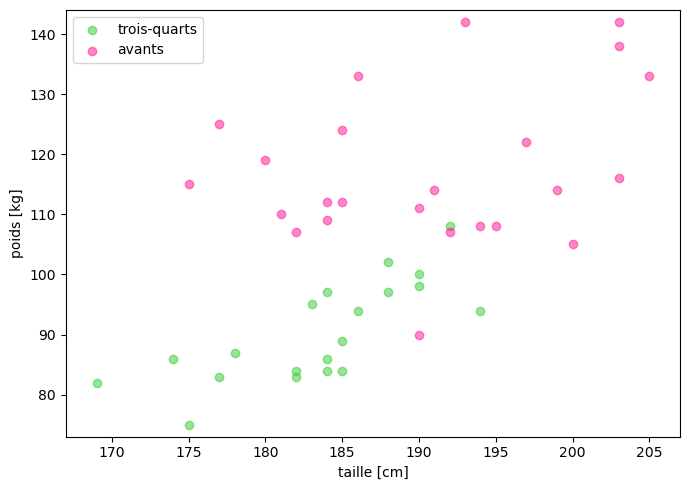

In [15]:
tree = Tree(X, Y, max_depth = 10, min_size=2, min_entropy=1e-4)
tree.plot("taille [cm]", "poids [kg]", "trois-quarts", "avants")

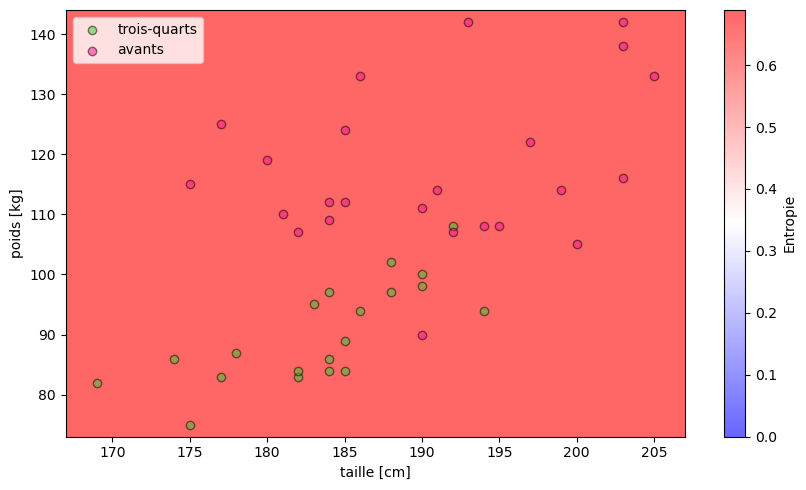

In [16]:
tree.plot_entropy("taille [cm]", "poids [kg]", "trois-quarts", "avants")

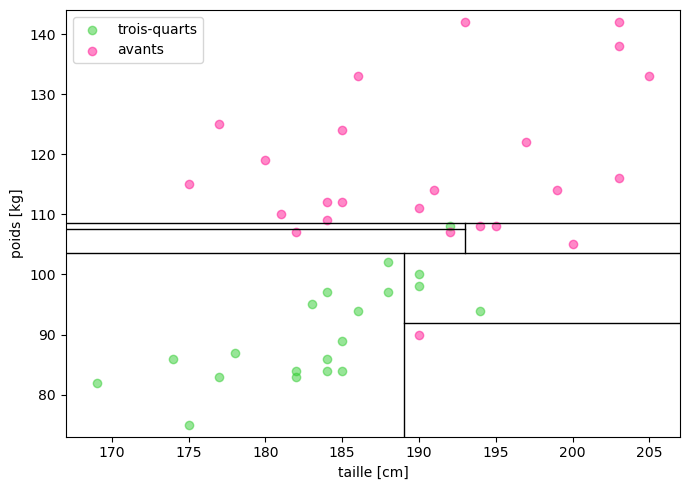

In [17]:
tree.fit()
tree.plot("taille [cm]", "poids [kg]", "trois-quarts", "avants")

In [18]:
tree.predict(np.array([185., 90.]))

np.float64(0.0)

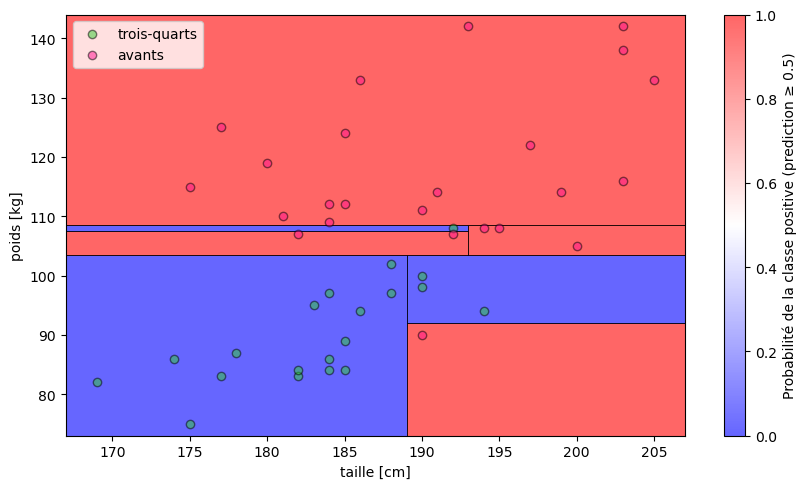

In [19]:
tree.plot_predictions("taille [cm]", "poids [kg]", "trois-quarts", "avants")

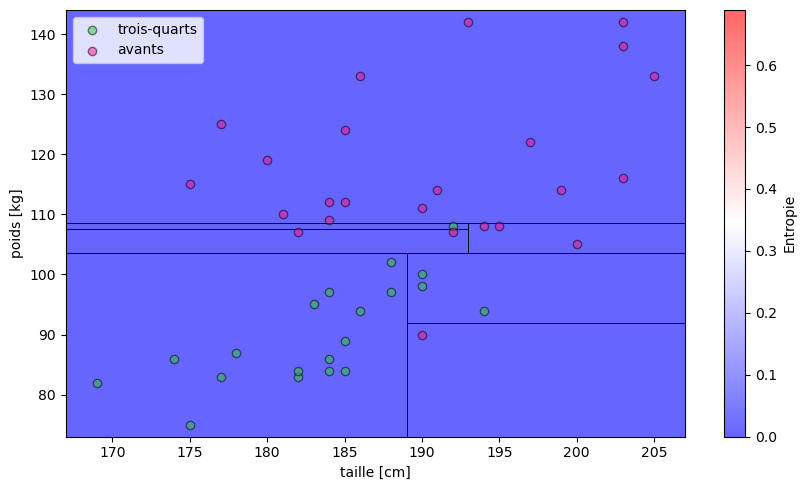

In [20]:
tree.plot_entropy("taille [cm]", "poids [kg]", "trois-quarts", "avants")

In [21]:
np.random.seed(12)

In [22]:
X1, X2, X, Y = lineaire(200)

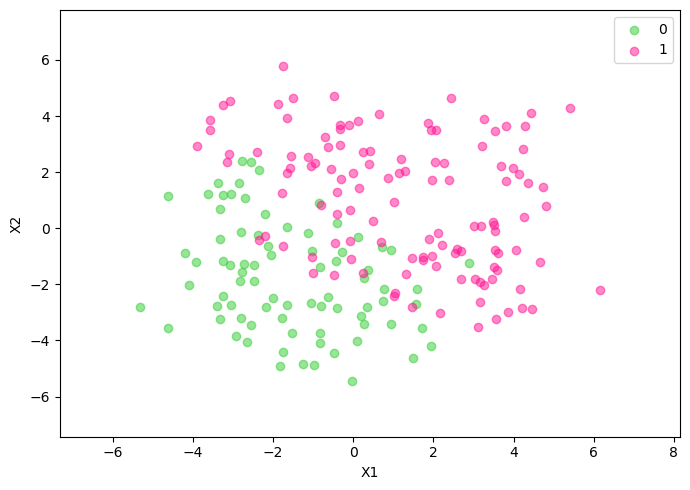

In [23]:
tree = Tree(X, Y, max_depth = 30, min_size=1, min_entropy=1e-6)
tree.plot("X1", "X2", "0", "1")

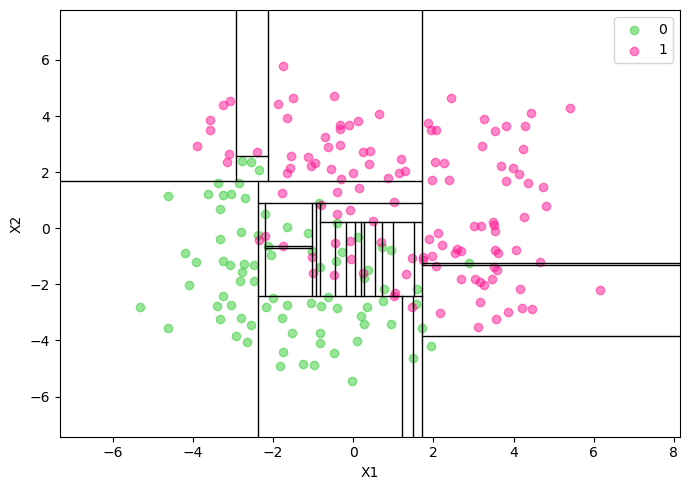

In [24]:
tree.fit()
tree.plot("X1", "X2", "0", "1")

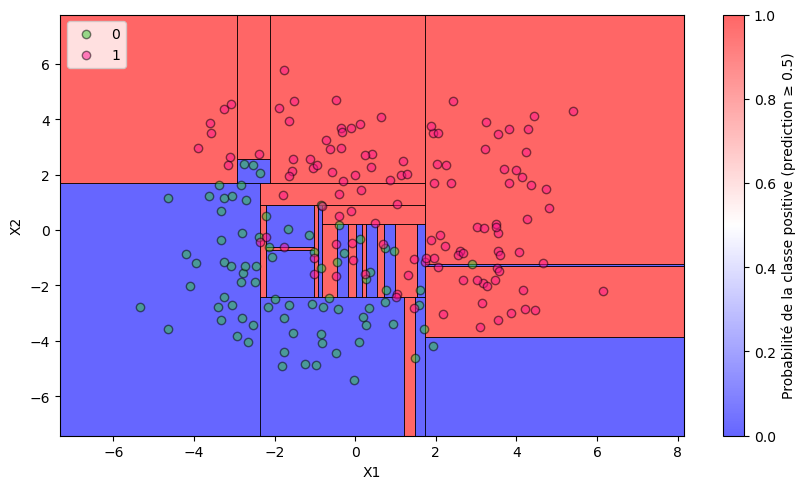

In [25]:
tree.plot_predictions("X1", "X2", "0", "1")

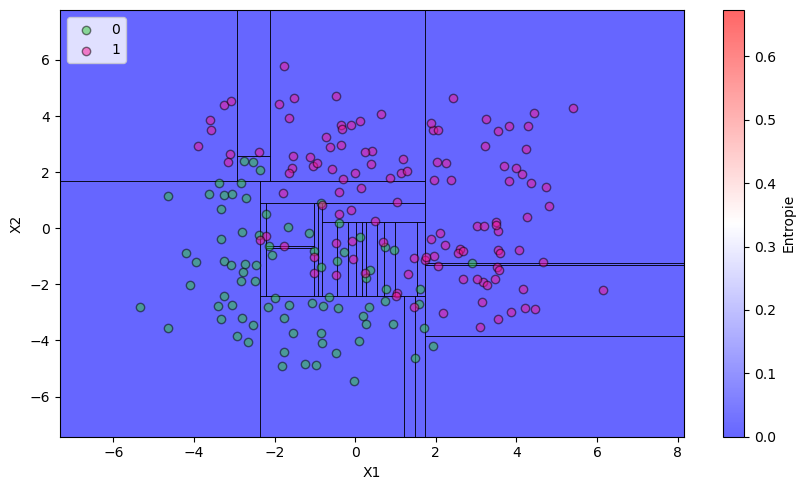

In [26]:
tree.plot_entropy("X1", "X2", "0", "1")

In [30]:
X1, X2, X, Y = rugby()
opt = dict(xlabel="Taille [cm]", ylabel="Poids [kg]", class0="Trois-quarts", class1="Avants")
# X1, X2, X, Y = lineaire(n=200, sigma=2.0)
# X1, X2, X, Y = lunes(n=200)
# opt = dict(xlabel="X1", ylabel="X2", class0="0", class1="1")
tree = Tree(X, Y, max_depth = 10, min_size=2, min_entropy=1e-4)

In [31]:
out = widgets.Output(layout=widgets.Layout(height='525px', border='1px solid #ddd'))

button = widgets.Button(
    description="Prochaine Découpe ✂️",
    button_style='success', 
    tooltip="Avance l'algorithme d'un pas"
)

ui = widgets.HBox([button], layout=widgets.Layout(justify_content='space-around'))

def on_button_clicked(b):
    result = tree.advance()
    with out:
        clear_output(wait=True)
        if result is None:
            print("🛑 L'arbre est terminé ! Tous les critères d'arrêt sont atteints.")
            button.disabled = True
            button.button_style = 'danger'
        else:
            feature, threshold = result
            nom_variable = "Taille" if feature == 0 else "Poids"
            print(f"✅ Nouvelle découpe trouvée sur : {nom_variable} au seuil {threshold:.2f}")
        tree.plot_entropy(**opt)
        # plt.figure()
        plt.show()
        plt.close()


button.on_click(on_button_clicked)

display(ui, out)

with out:
    print("État initial du jeu de données (Nœud Racine). Cliquez sur le bouton pour commencer !")
    tree.plot_entropy(**opt)
    plt.show()

Output(layout=Layout(border_bottom='1px solid #ddd', border_left='1px solid #ddd', border_right='1px solid #dd…

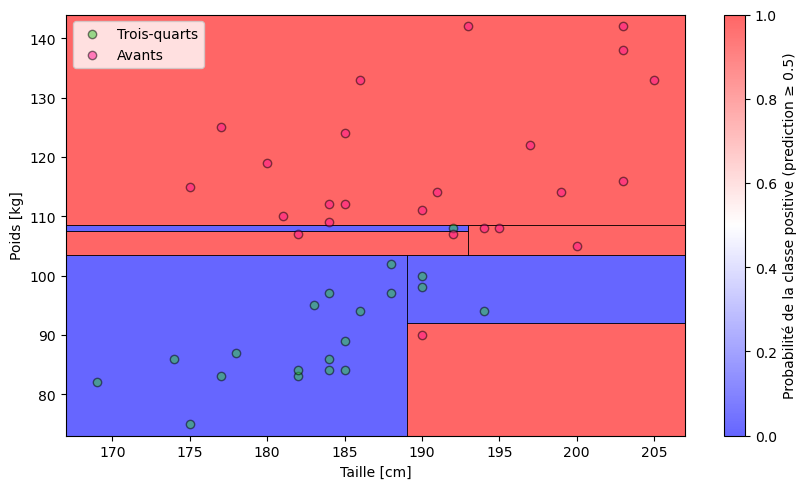

In [32]:
tree.plot_predictions(**opt)